In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score, classification_report, confusion_matrix)
import joblib

Этап 1: Исследовательский анализ данных (EDA)

In [170]:
# 1.	Загрузка данных, вывод информации (.info(), .describe()).
df = pd.read_csv('avocado_ripeness_dataset.csv')

In [171]:
df

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking
...,...,...,...,...,...,...,...,...,...
245,94.1,83,80,58,dark green,72,254,134,hard
246,21.6,17,36,19,black,47,182,240,firm-ripe
247,14.0,4,40,17,black,37,188,274,ripe
248,61.5,63,87,75,green,65,261,162,pre-conditioned


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firmness        250 non-null    float64
 1   hue             250 non-null    int64  
 2   saturation      250 non-null    int64  
 3   brightness      250 non-null    int64  
 4   color_category  250 non-null    object 
 5   sound_db        250 non-null    int64  
 6   weight_g        250 non-null    int64  
 7   size_cm3        250 non-null    int64  
 8   ripeness        250 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 17.7+ KB


In [173]:
df.describe().round()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3
count,250.0,250.0,250.0,250.0,250.0,250.0,250.0
mean,51.0,126.0,64.0,45.0,58.0,220.0,209.0
std,27.0,117.0,17.0,19.0,14.0,34.0,56.0
min,10.0,1.0,30.0,10.0,30.0,152.0,100.0
25%,26.0,25.0,51.0,31.0,47.0,193.0,155.0
50%,49.0,77.0,65.0,46.0,60.0,220.0,218.0
75%,74.0,279.0,77.0,58.0,68.0,245.0,260.0
max,99.0,329.0,99.0,78.0,79.0,299.0,299.0


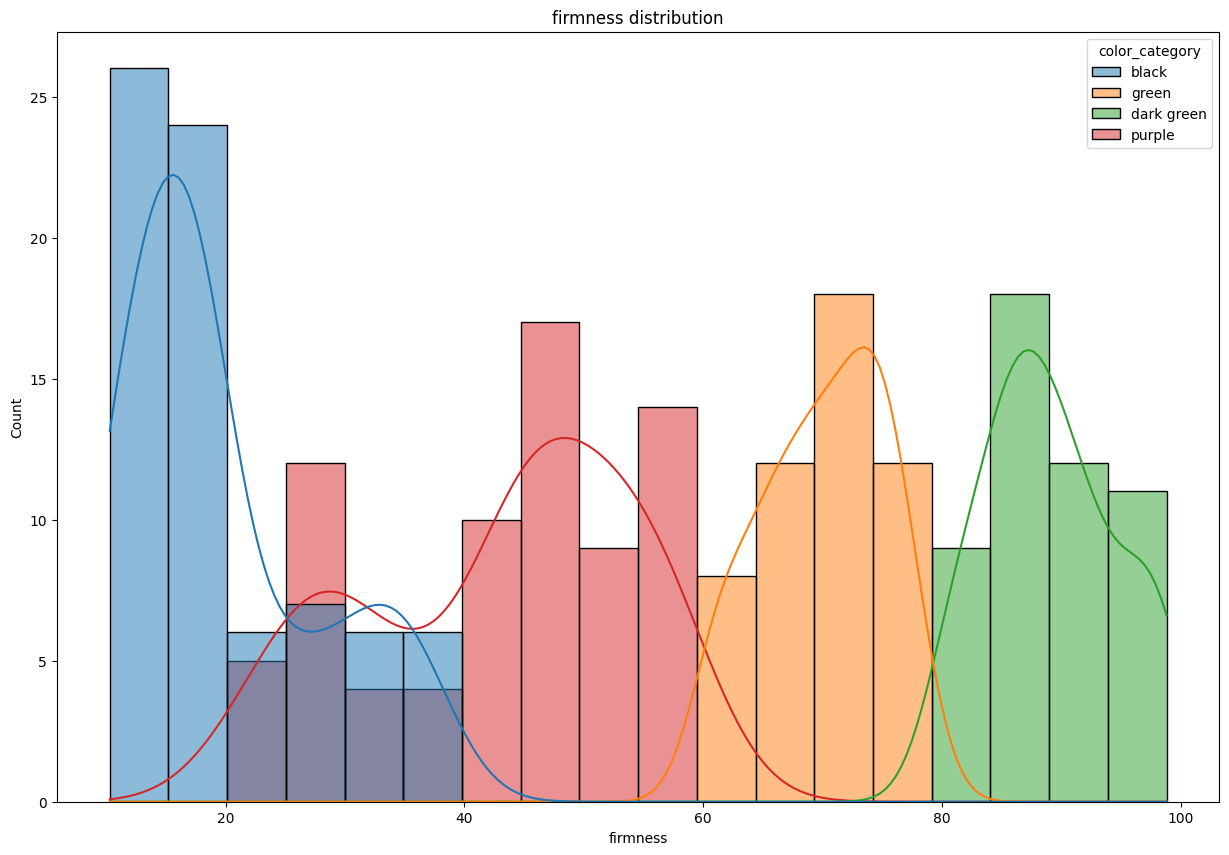

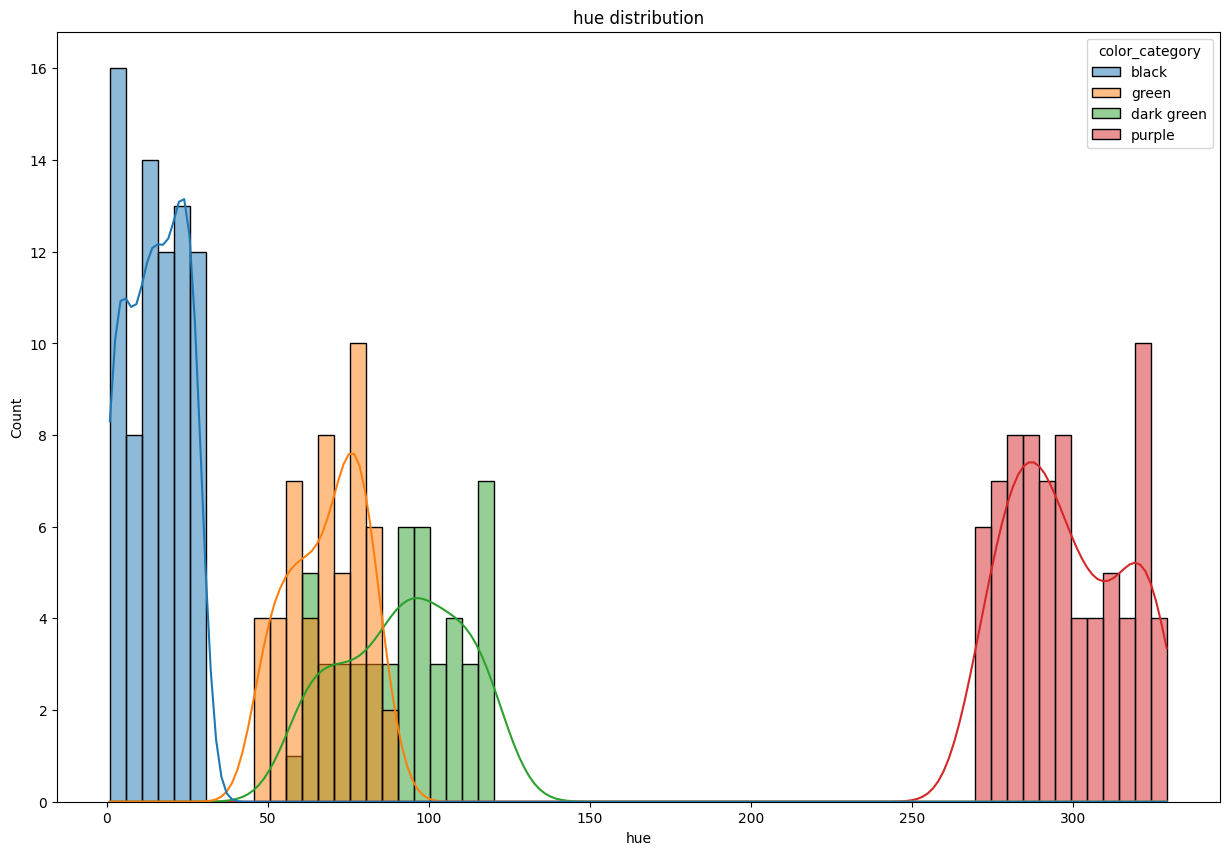

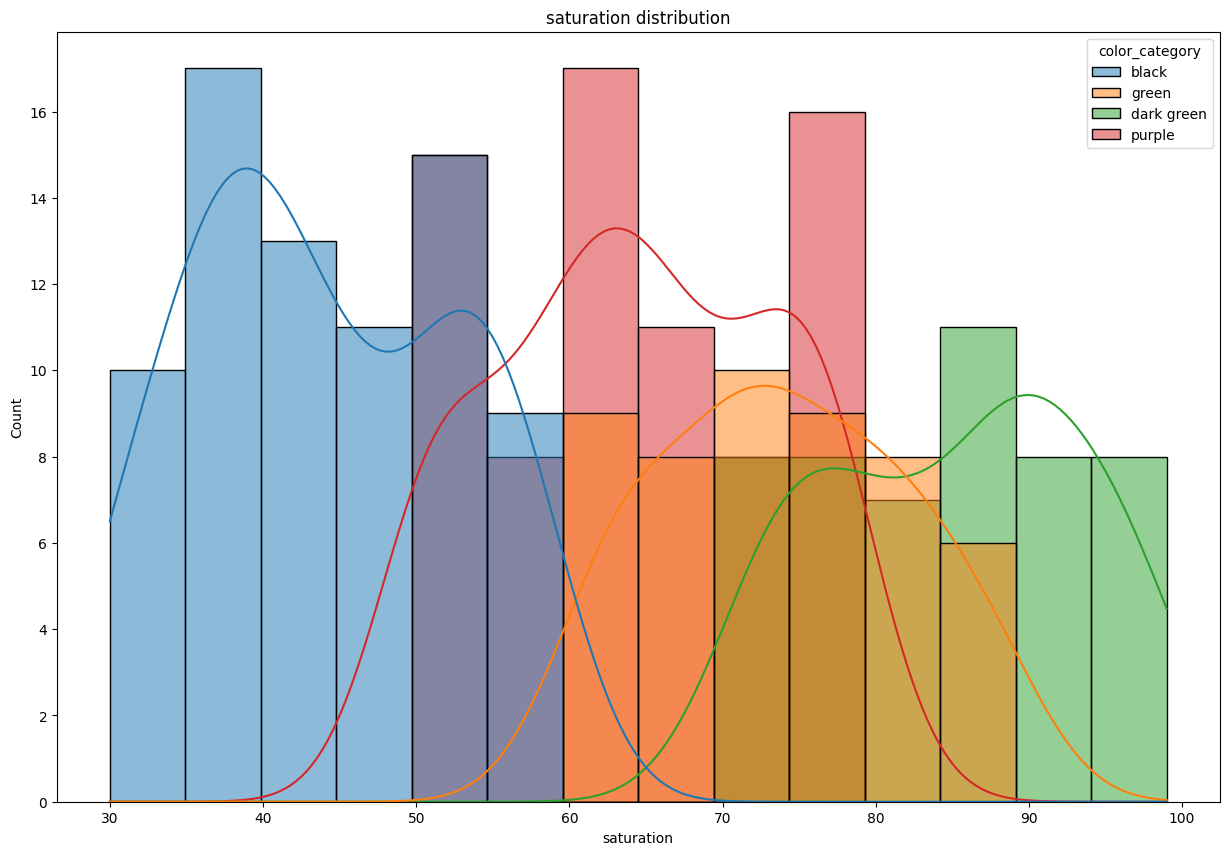

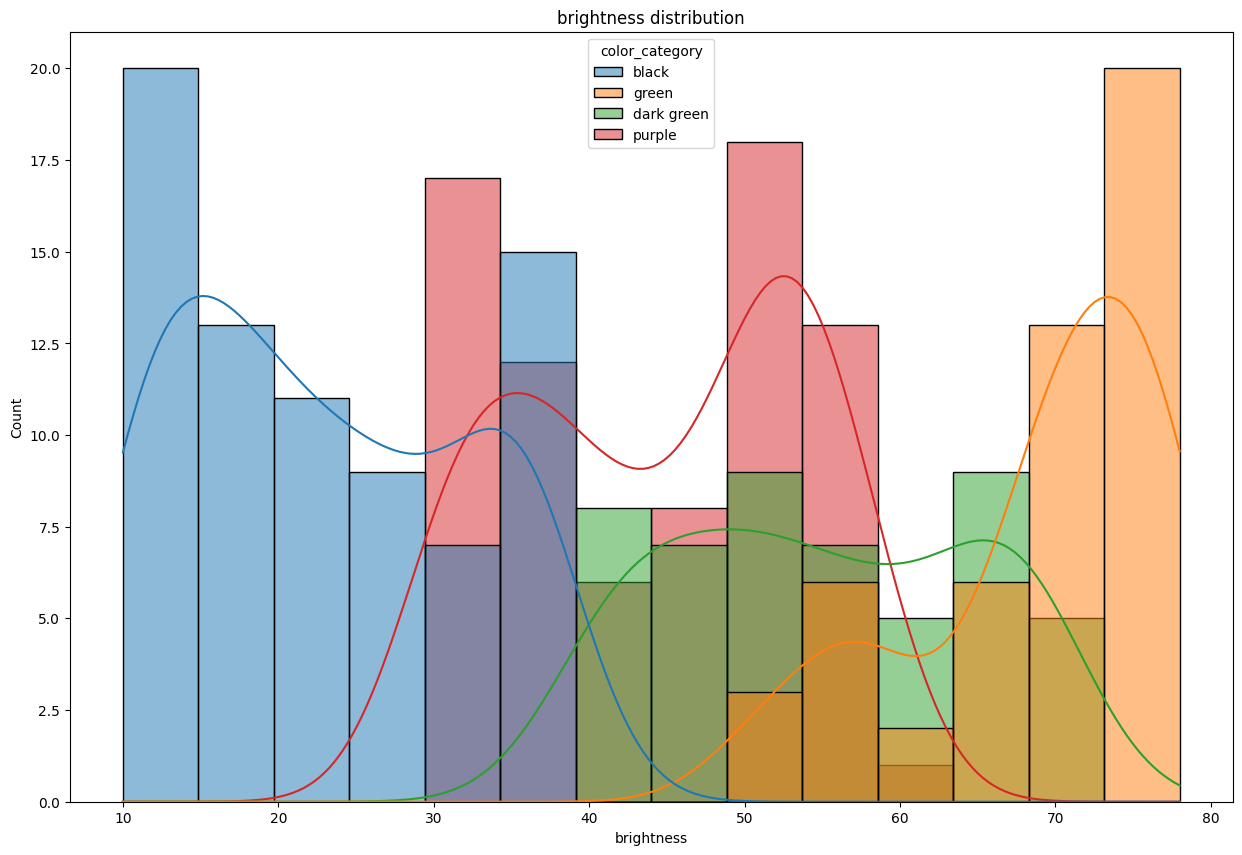

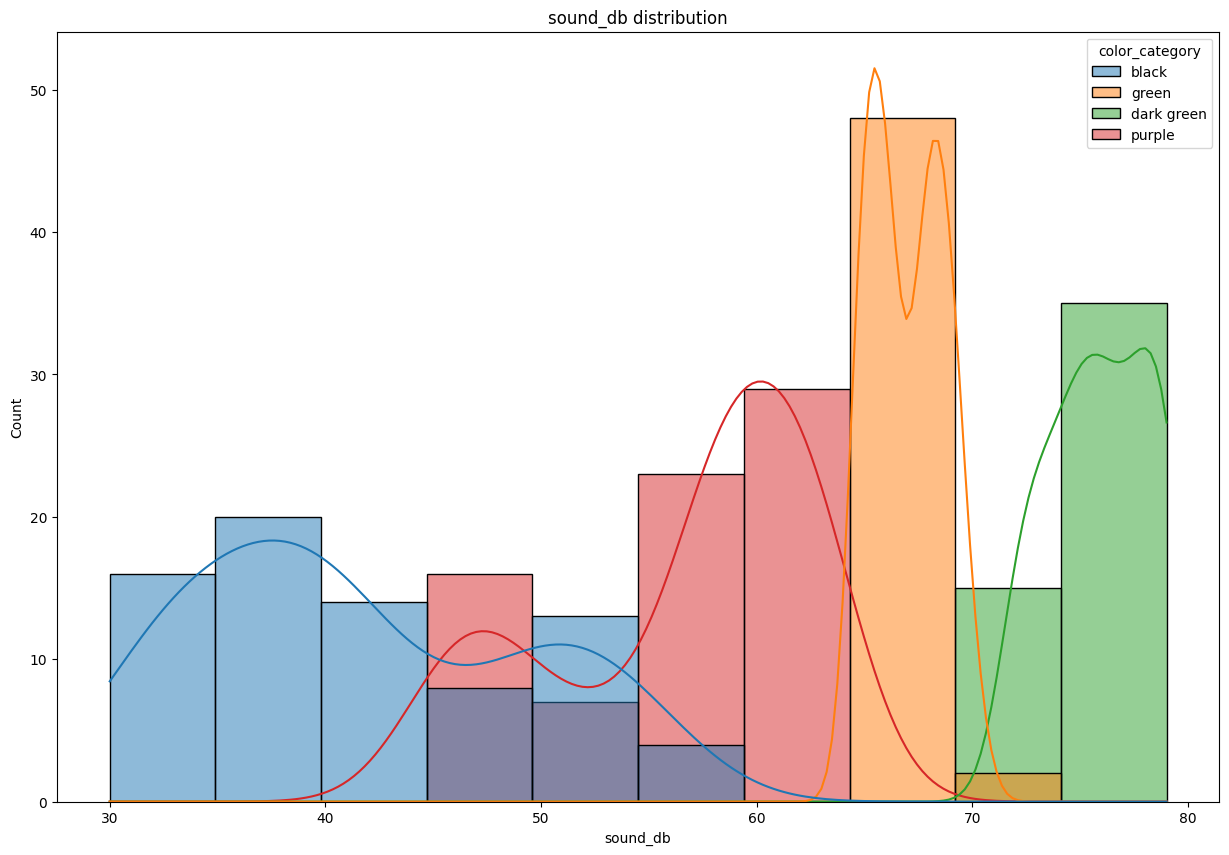

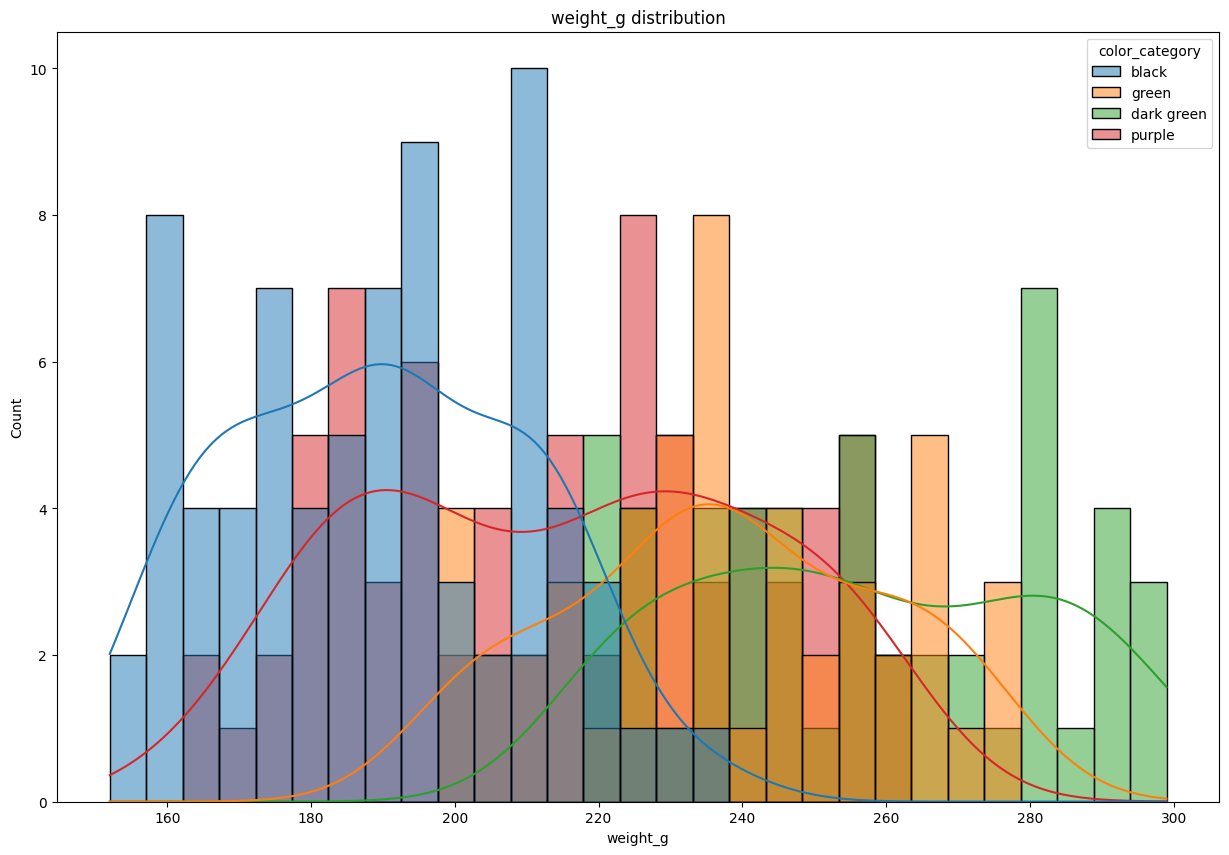

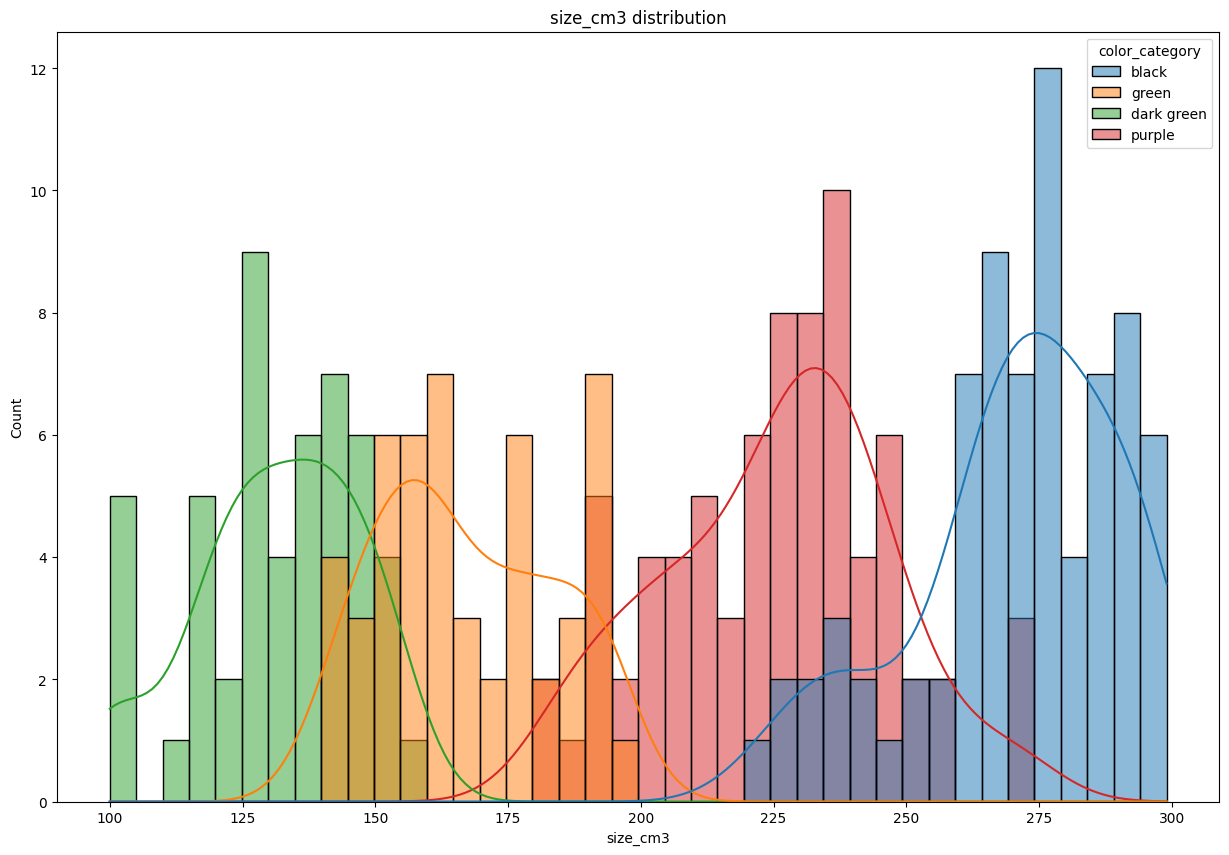

In [174]:
# 2.	Анализ распределения каждого признака (гистограммы, boxplot).
num_cols = ['firmness', 'hue', 'saturation', 'brightness',
            'sound_db', 'weight_g', 'size_cm3']

for col in num_cols:
    plt.figure(figsize=(15,10))
    sns.histplot(data=df, x=col, kde=True, binwidth=5, hue='color_category')
    plt.title(f'{col} distribution')
    plt.show()

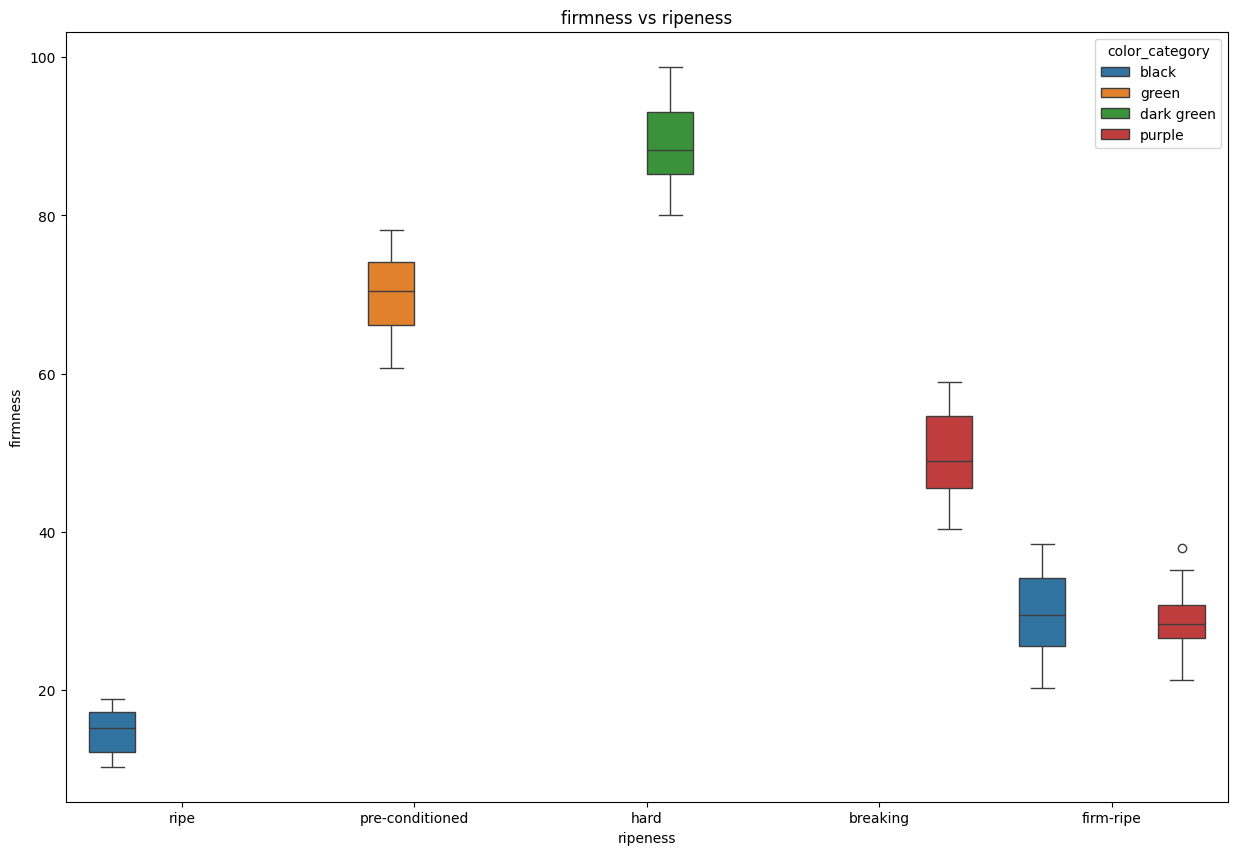

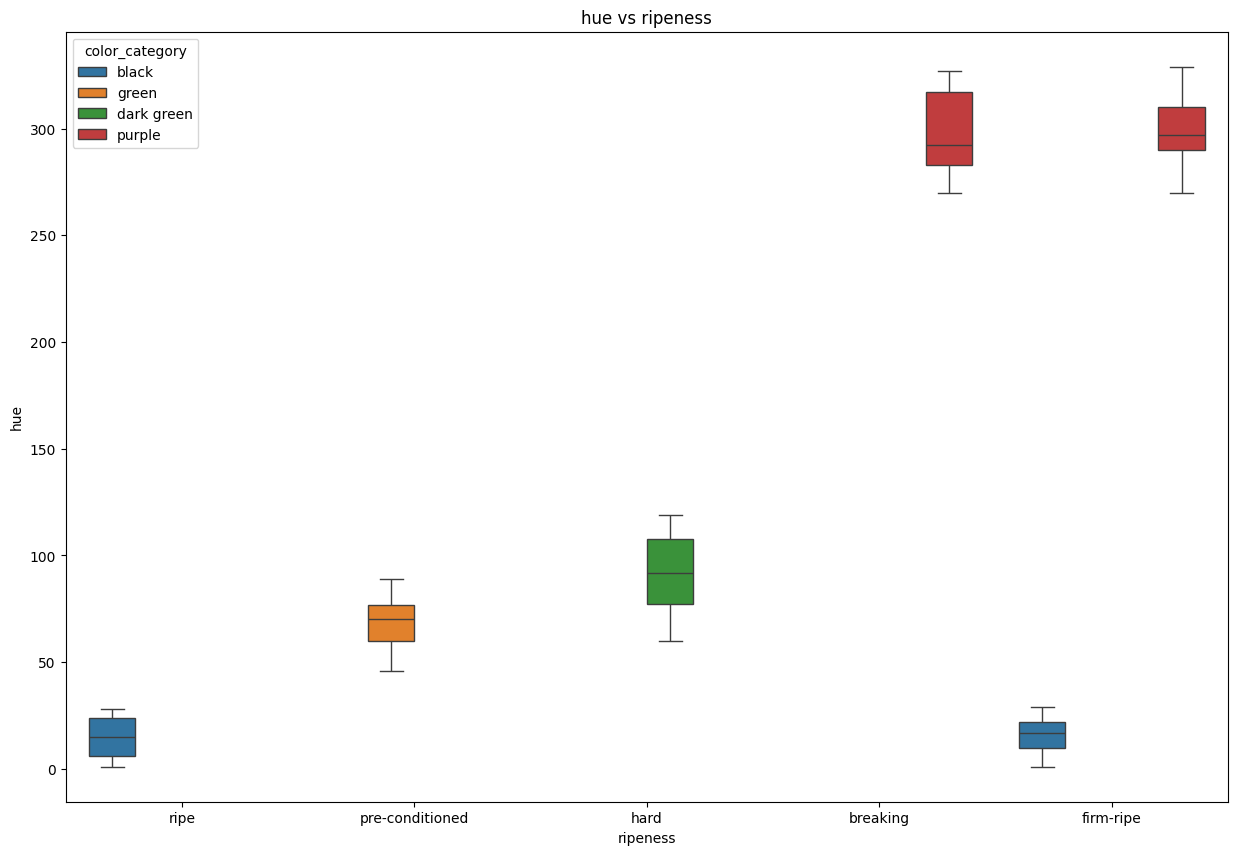

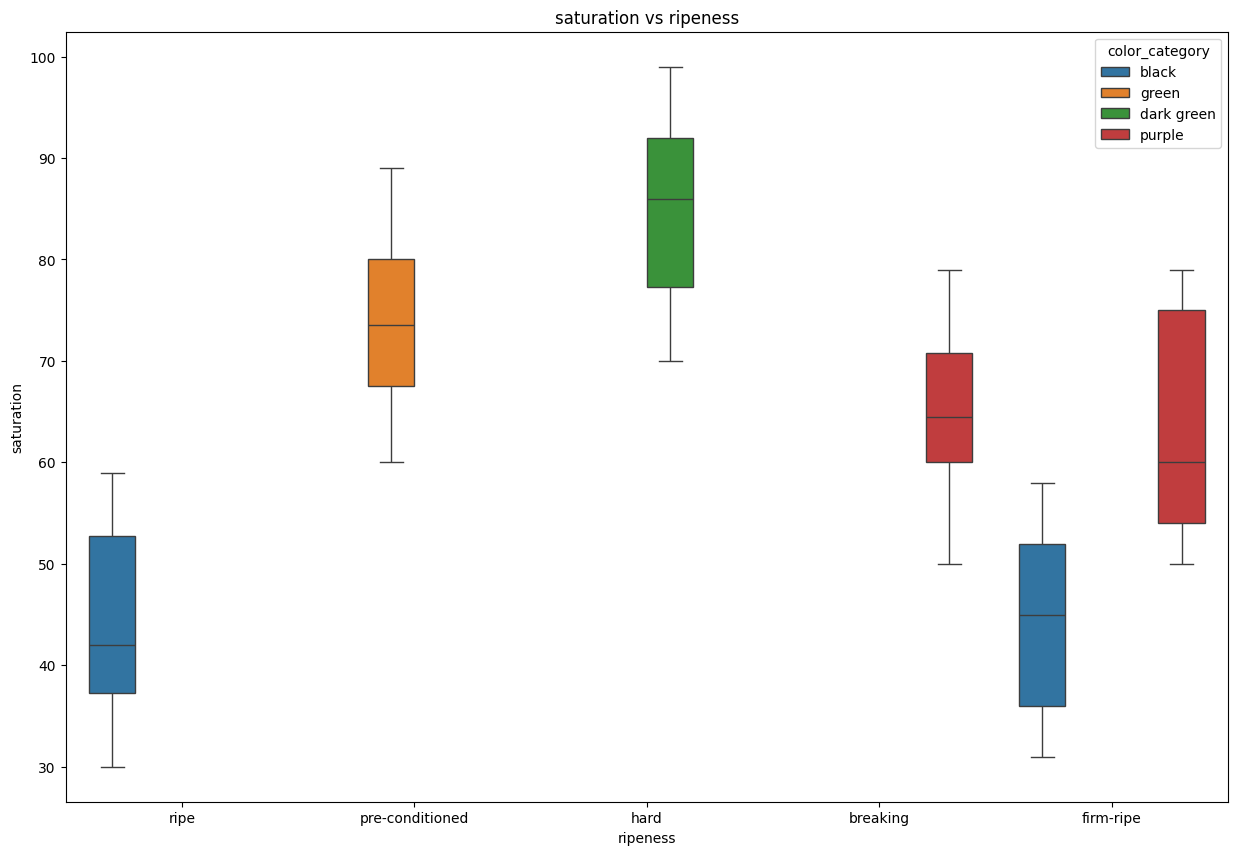

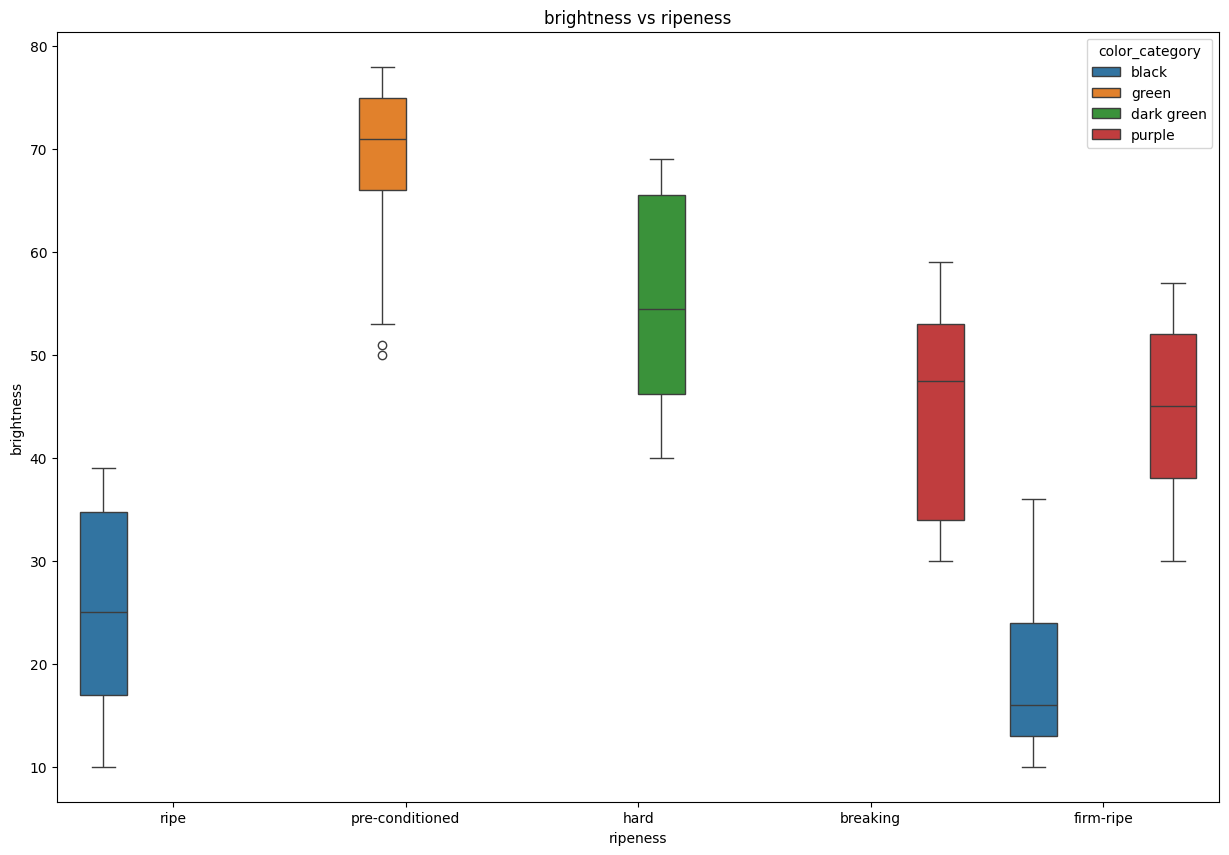

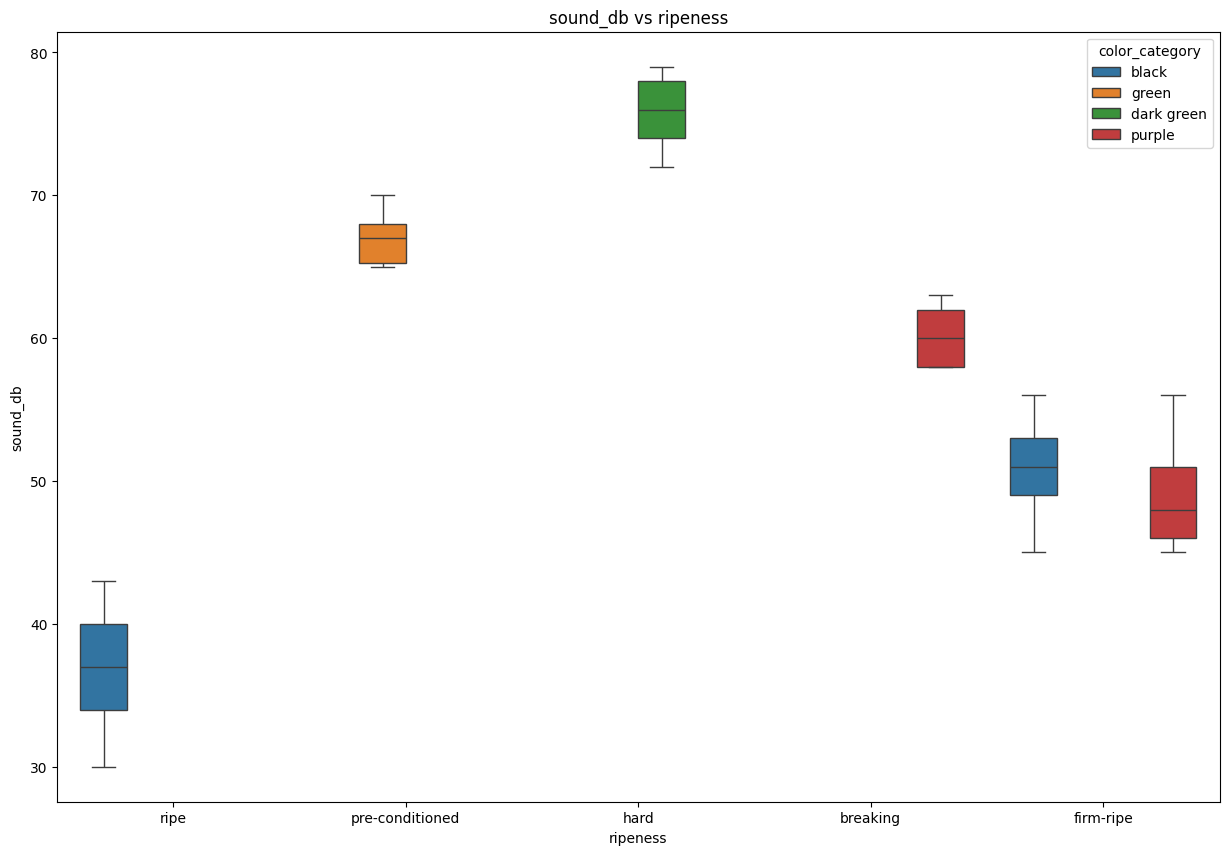

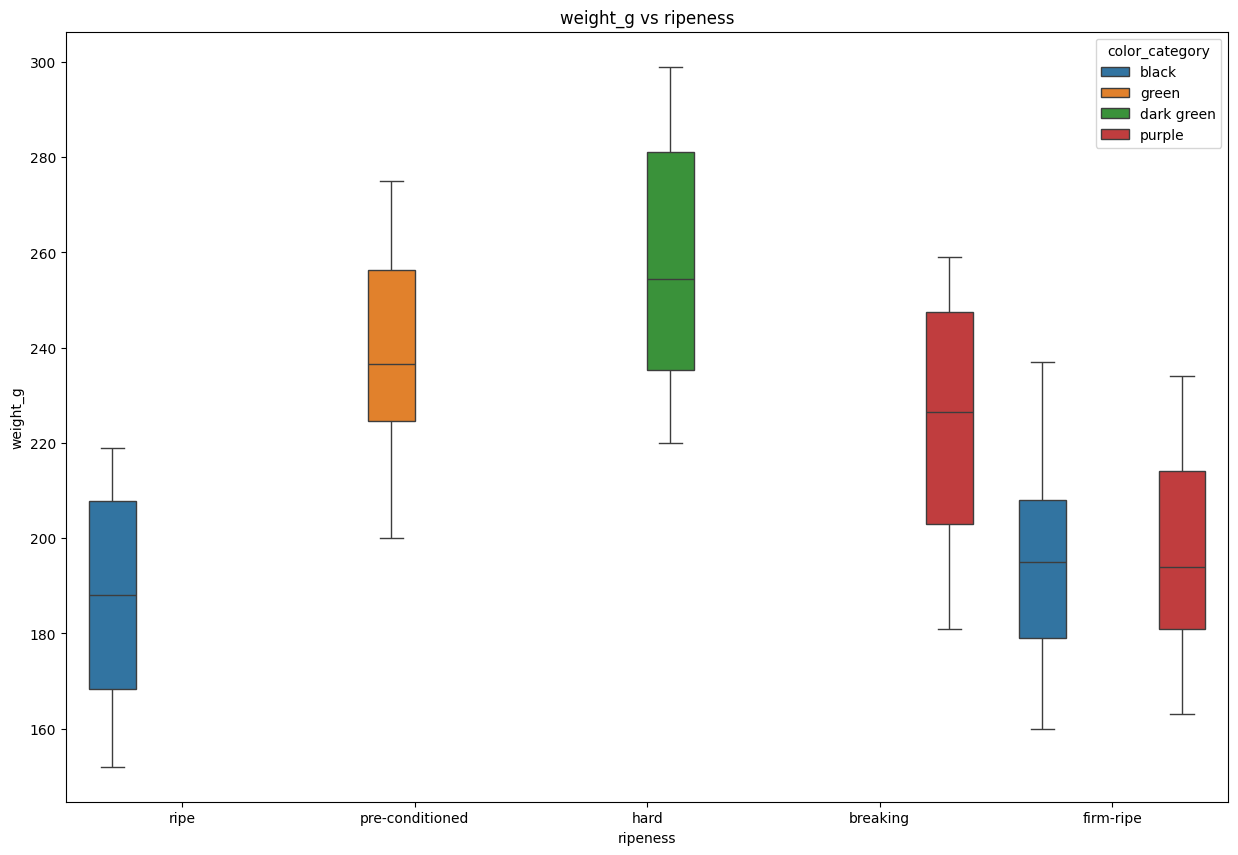

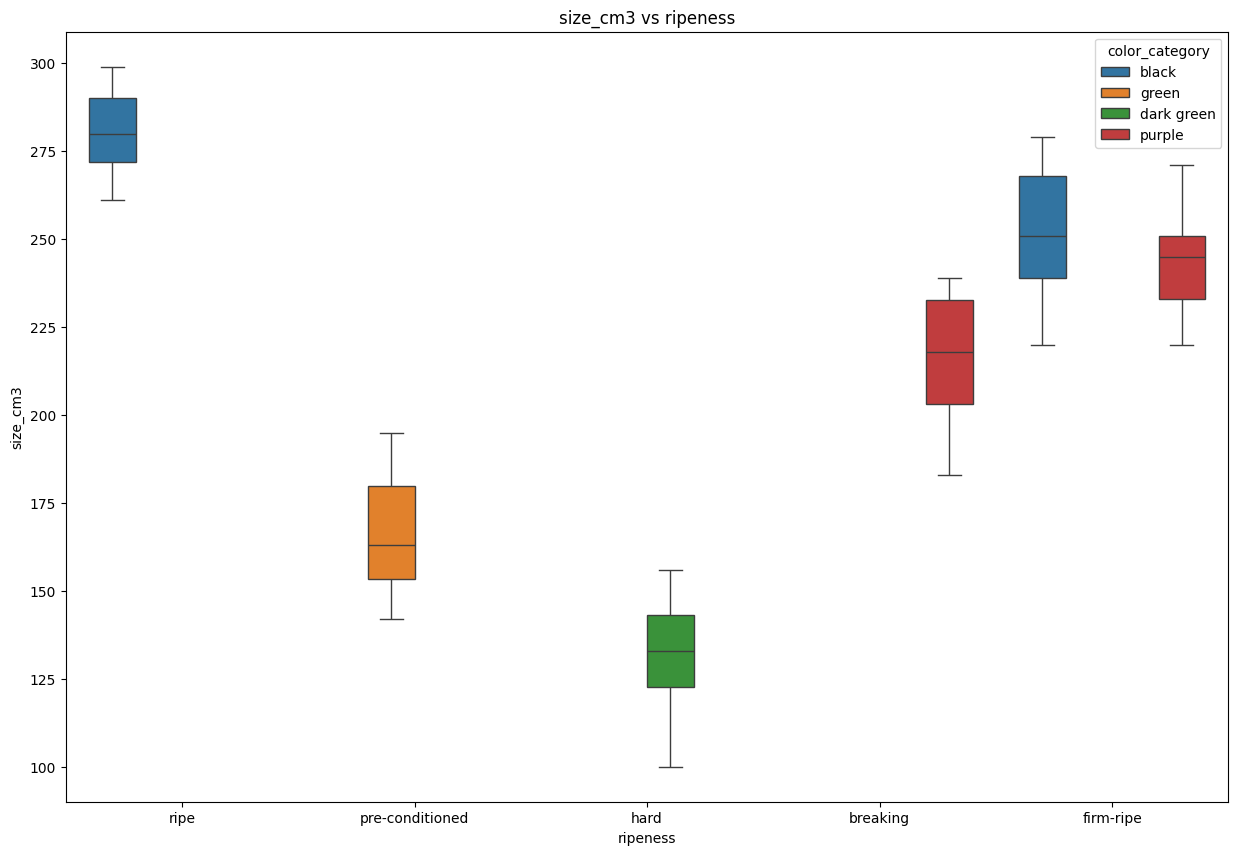

In [175]:
num_cols = ['firmness', 'hue', 'saturation', 'brightness',
            'sound_db', 'weight_g', 'size_cm3']

for col in num_cols:
    plt.figure(figsize=(15,10))
    sns.boxplot(x='ripeness', y=col, data=df, hue='color_category')
    plt.title(f'{col} vs ripeness')
    plt.show()

/tmp/ipykernel_564/2284312413.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ripeness', y=col, data=df, palette='Set2')


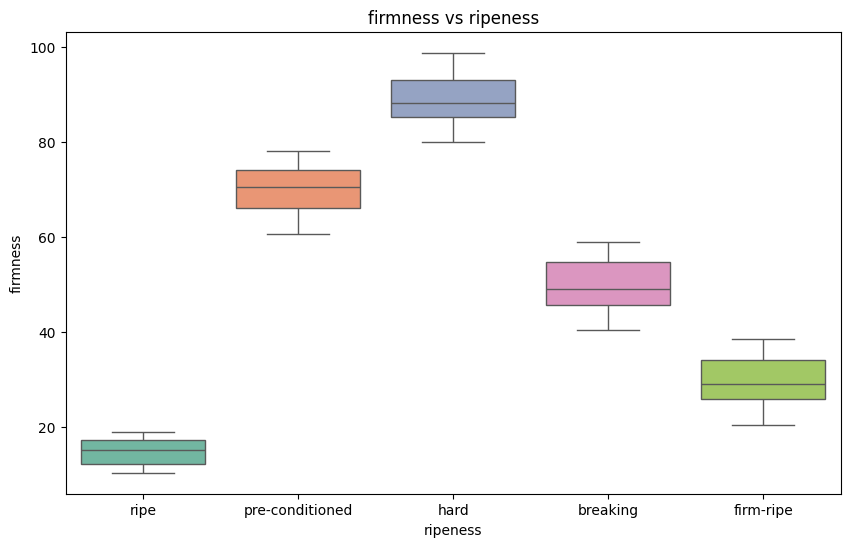

/tmp/ipykernel_564/2284312413.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ripeness', y=col, data=df, palette='Set2')


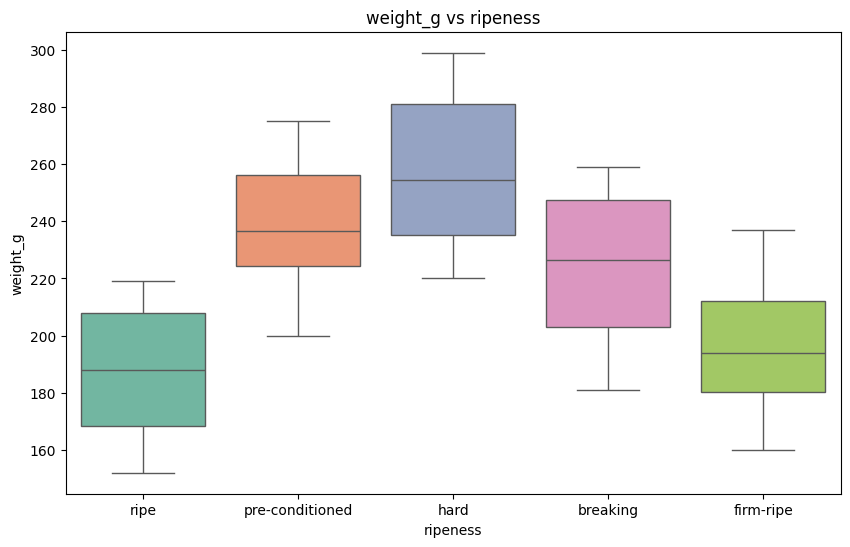

/tmp/ipykernel_564/2284312413.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ripeness', y=col, data=df, palette='Set2')


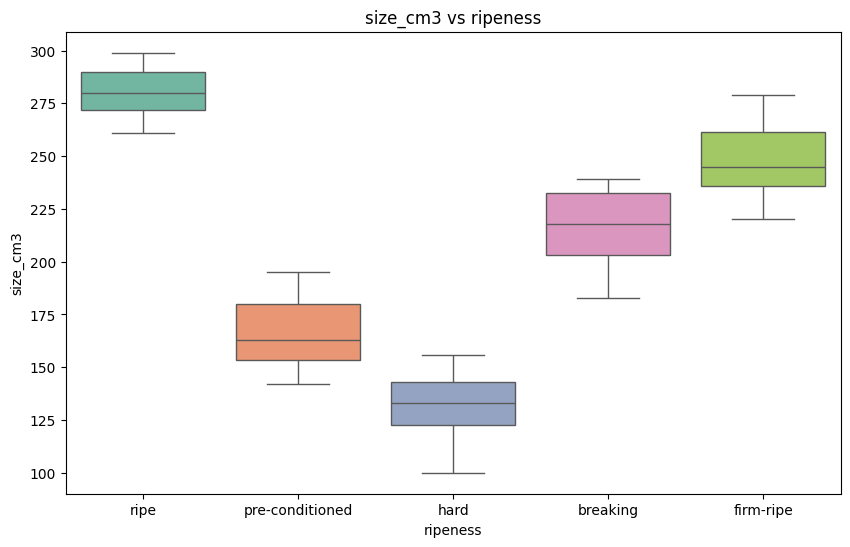

In [176]:
# 3.	Анализ зависимости признаков от ripeness:
# o	firmness, weight_g, size_cm3 vs ripeness
# o	hue, saturation, brightness vs color_category vs ripeness
features = ['firmness', 'weight_g', 'size_cm3']

for col in features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='ripeness', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs ripeness')
    plt.show()


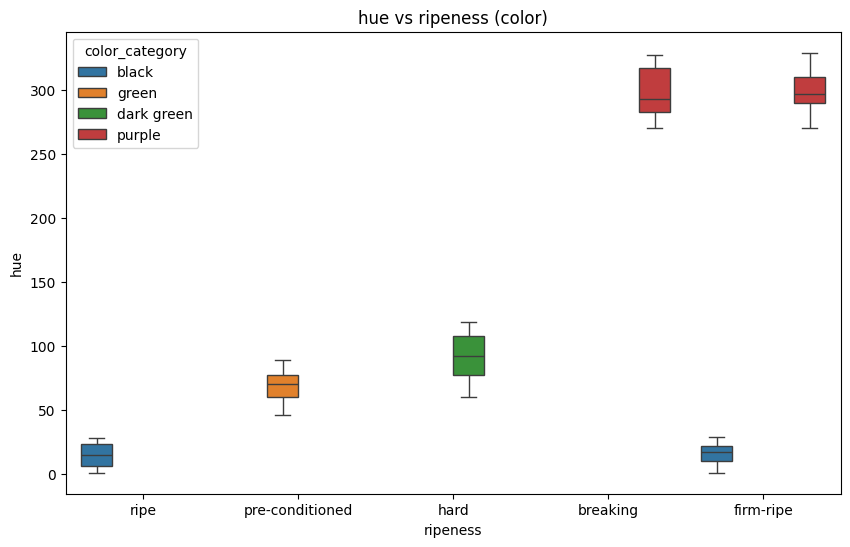

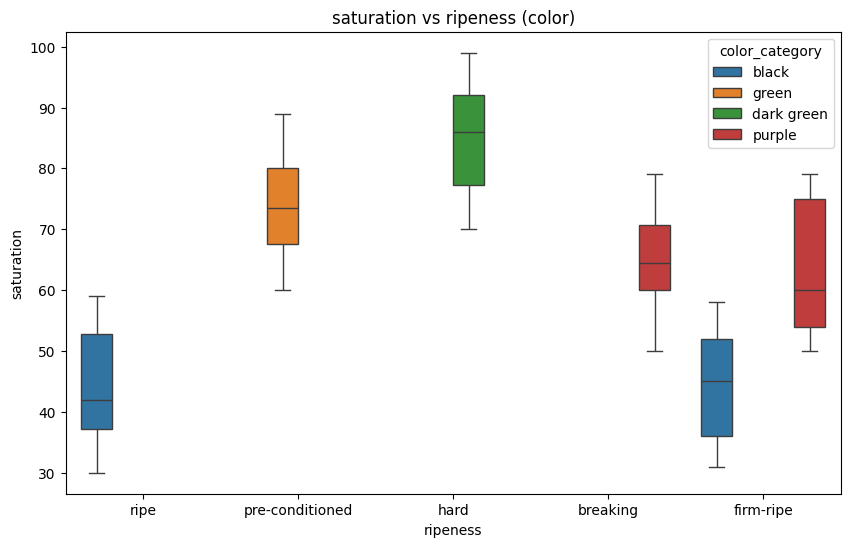

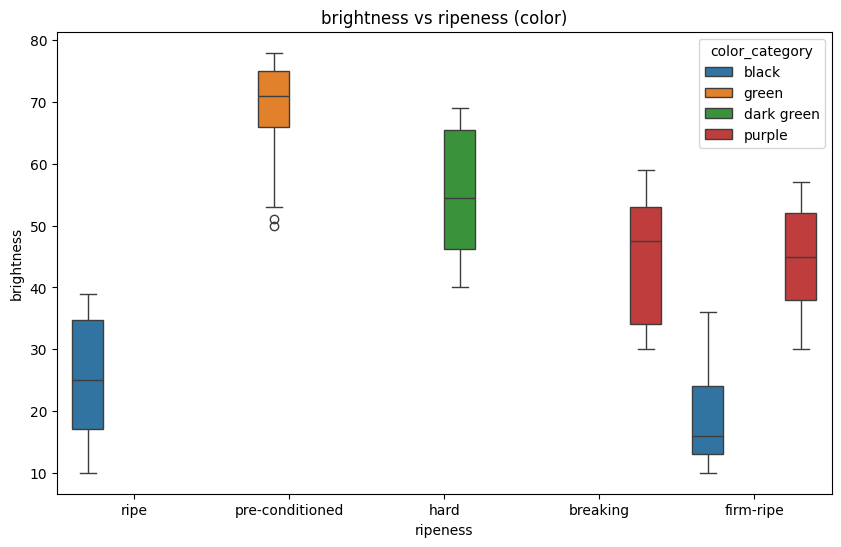

In [177]:
color_features = ['hue', 'saturation', 'brightness']

for col in color_features:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='ripeness', y=col, hue='color_category', data=df)
    plt.title(f'{col} vs ripeness (color)')
    plt.show()

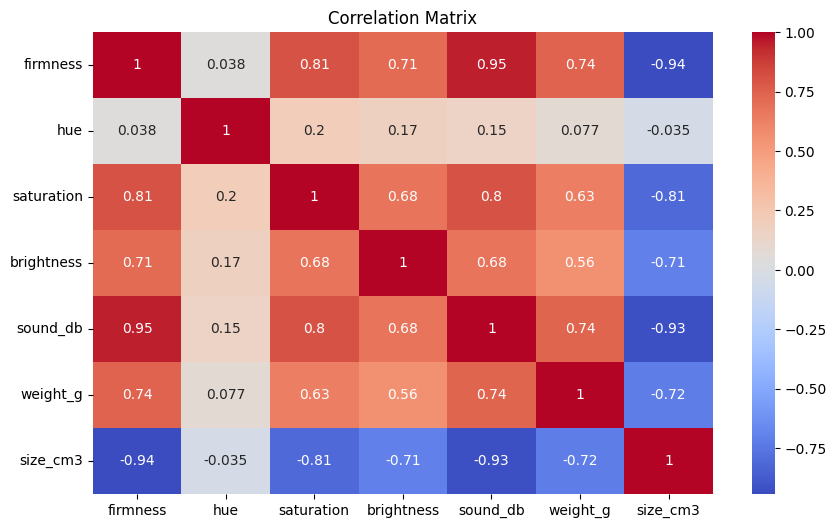

In [178]:
# 4.	Анализ корреляций между числовыми признаками (heatmap, pairplot).
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=['float64','int64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

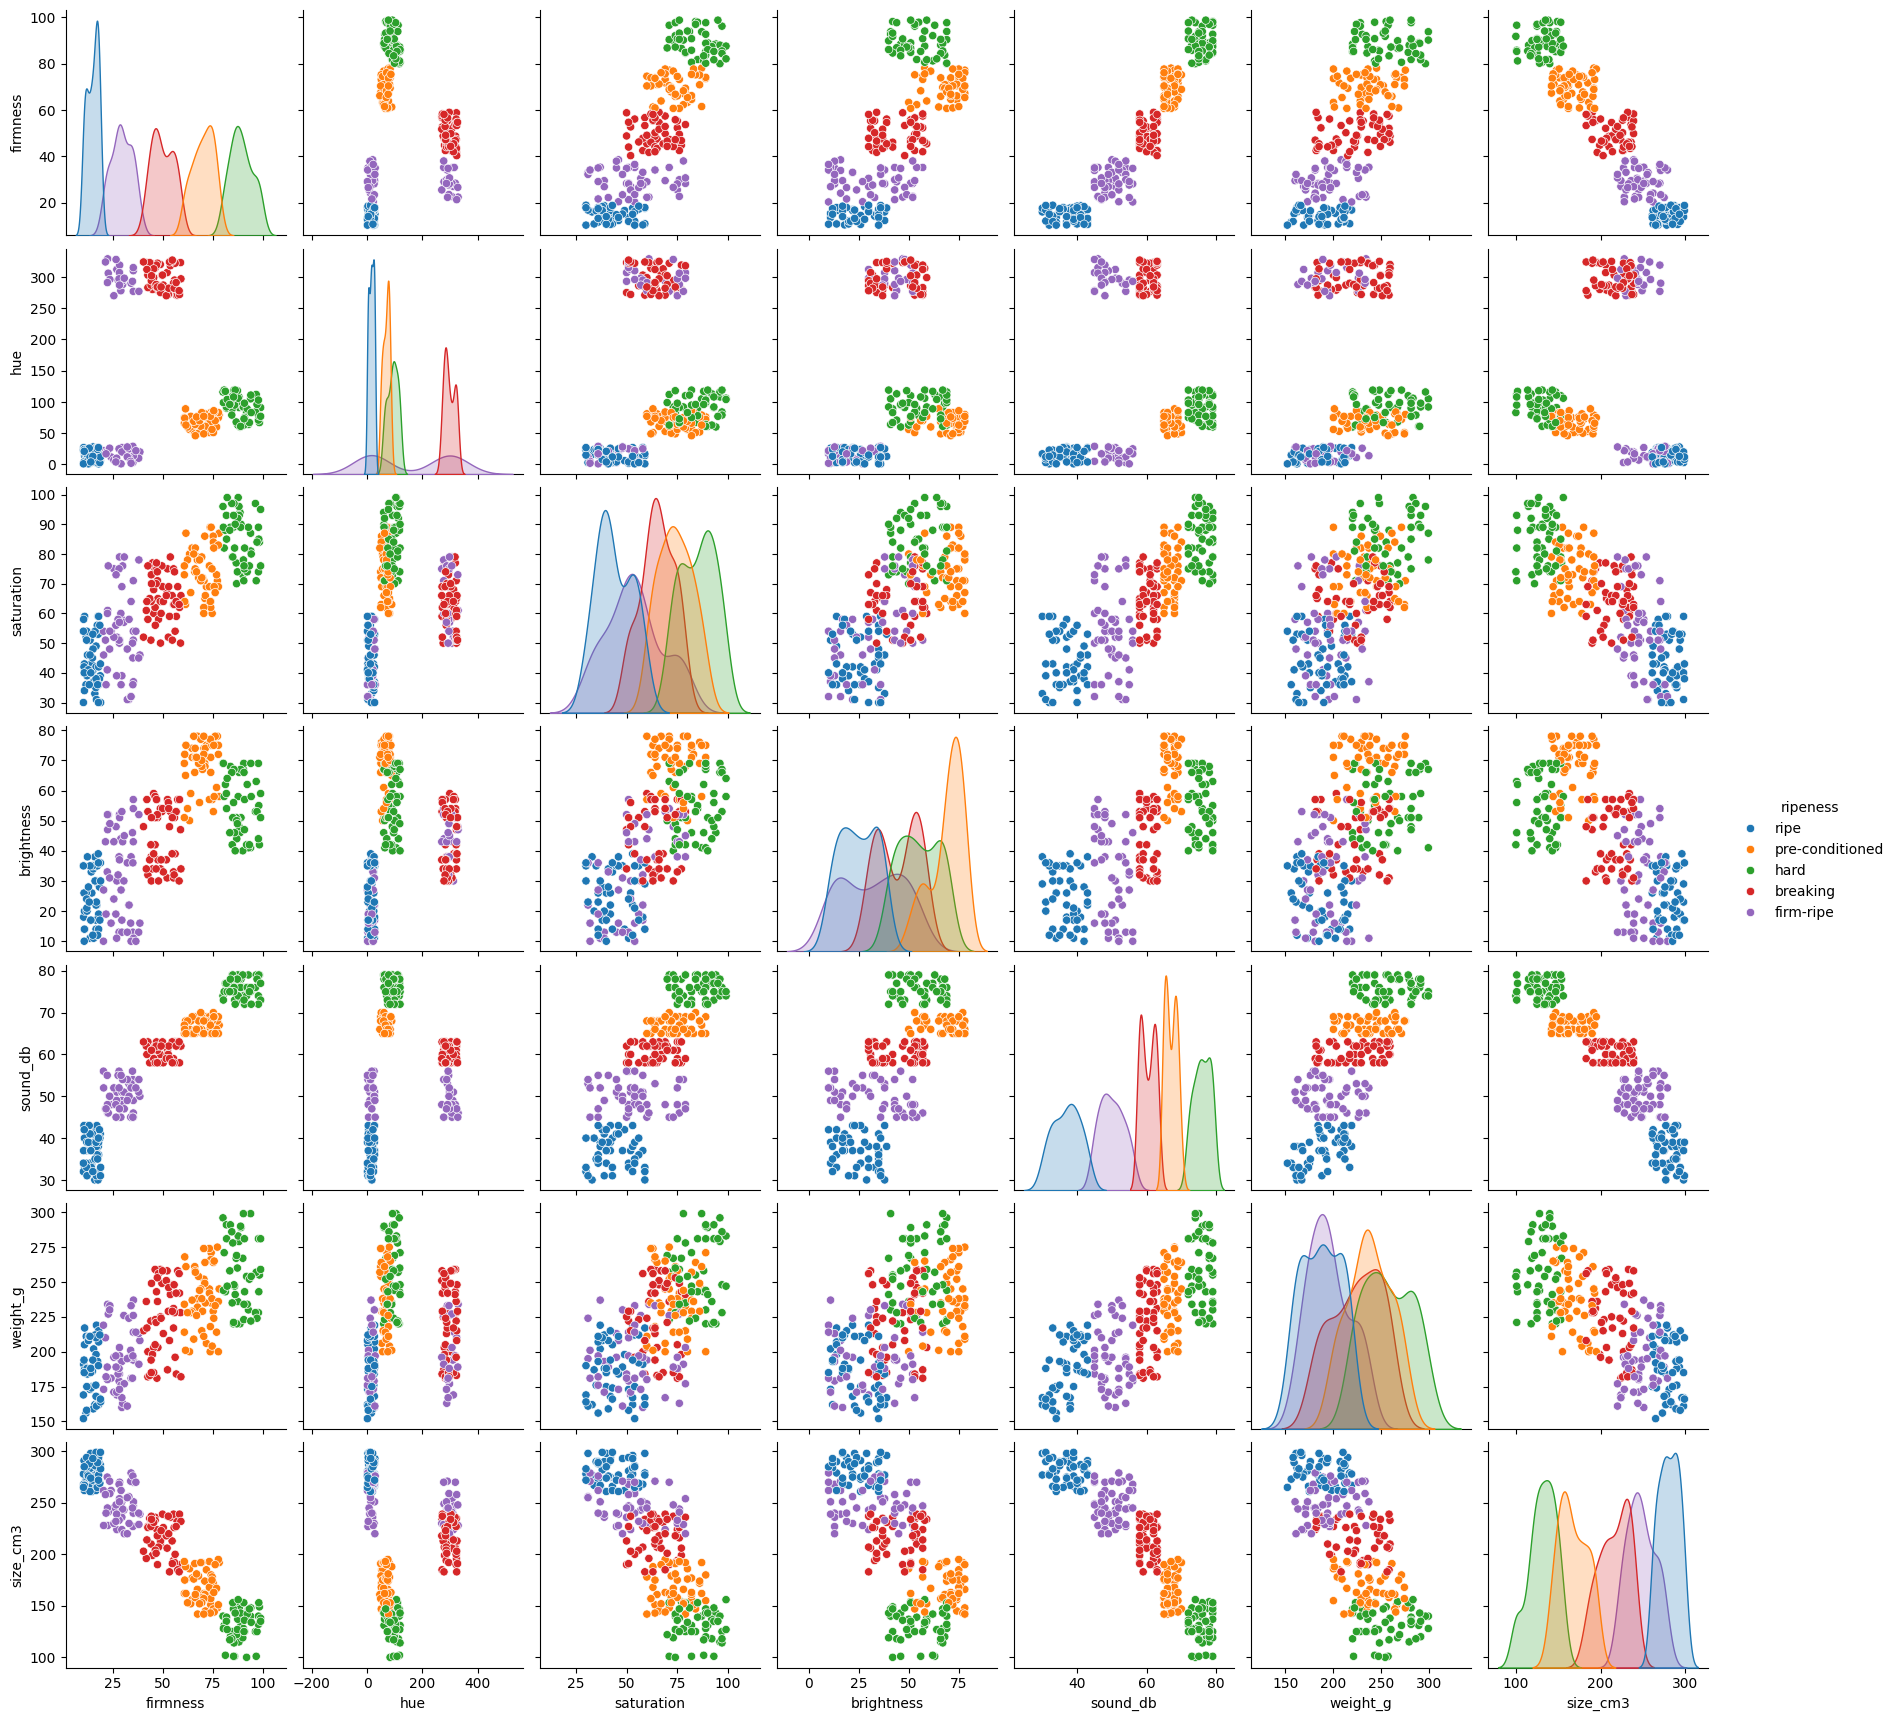

In [179]:
sns.pairplot(df, hue='ripeness')
plt.show()

In [180]:
# 5.	Проверка и обработка пропусков, выбросов.
df.isnull().sum()


,0
firmness,0
hue,0
saturation,0
brightness,0
color_category,0
sound_db,0
weight_g,0
size_cm3,0
ripeness,0


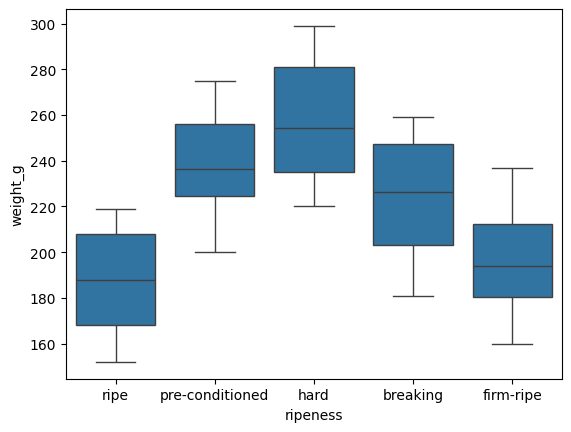

In [181]:
sns.boxplot(x='ripeness', y='weight_g', data=df)
plt.show()
#нету выбросов

Этап 2: Предобработка данных

In [182]:
#6.	Кодирование категориальных признаков (color_category) — OneHot или Label Encoding.
df['ripeness'] = df['ripeness'].map({'hard': 1, 'pre-conditioned': 2, 'breaking': 3, 'firm-ripe': 4, 'ripe': 5})


In [183]:
df = pd.get_dummies(df, columns=['color_category'], drop_first=True, dtype=int)

In [184]:
df

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3,ripeness,color_category_dark green,color_category_green,color_category_purple
0,14.5,19,40,26,34,175,261,5,0,0,0
1,71.7,53,69,75,69,206,185,2,0,1,0
2,88.5,60,94,46,79,220,143,1,1,0,0
3,93.8,105,87,41,75,299,140,1,1,0,0
4,42.5,303,58,32,63,200,227,3,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
245,94.1,83,80,58,72,254,134,1,1,0,0
246,21.6,17,36,19,47,182,240,4,0,0,0
247,14.0,4,40,17,37,188,274,5,0,0,0
248,61.5,63,87,75,65,261,162,2,0,1,0


In [185]:
# 7.	Масштабирование числовых признаков (MinMaxScaler, StandardScaler).

scaler = StandardScaler()
scaler_data = scaler.fit_transform(df.drop(columns='ripeness'))

In [186]:
scaler_data

array([[-1.32675715, -0.91480846, -1.4044229 , ..., -0.5       ,
        -0.5       , -0.65465367],
       [ 0.77440207, -0.62396945,  0.26778371, ..., -0.5       ,
         2.        , -0.65465367],
       [ 1.39152576, -0.56409082,  1.70934113, ...,  2.        ,
        -0.5       , -0.65465367],
       ...,
       [-1.34512393, -1.04311979, -1.4044229 , ..., -0.5       ,
        -0.5       , -0.65465367],
       [ 0.39971983, -0.53842856,  1.30570505, ..., -0.5       ,
         2.        , -0.65465367],
       [-1.20553643, -0.84637575, -1.98104587, ..., -0.5       ,
        -0.5       , -0.65465367]])

In [187]:
# 8.	Формирование X и y (разделение признаков и целевой переменной).
x = scaler_data
y = df['ripeness']

In [188]:
# 9.	Разделение на обучающую и тестовую выборки (например, 80/20).
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Этап 3: Моделирование

In [189]:
# 10.	Обучение нескольких моделей классификации: Logistic Regression (базовая модель)
log_model = LogisticRegression()


In [190]:
log_model.fit(x_train, y_train)

LogisticRegression()

In [191]:
y_pred = log_model.predict(x_test)

In [192]:
#11.	Оценка моделей:	Accuracy
Accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {Accuracy}')


Accuracy: 1.0


In [193]:
joblib.dump(log_model, 'log_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [194]:
df.columns

Index(['firmness', 'hue', 'saturation', 'brightness', 'sound_db', 'weight_g',
       'size_cm3', 'ripeness', 'color_category_dark green',
       'color_category_green', 'color_category_purple'],
      dtype='object')

In [195]:
df

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3,ripeness,color_category_dark green,color_category_green,color_category_purple
0,14.5,19,40,26,34,175,261,5,0,0,0
1,71.7,53,69,75,69,206,185,2,0,1,0
2,88.5,60,94,46,79,220,143,1,1,0,0
3,93.8,105,87,41,75,299,140,1,1,0,0
4,42.5,303,58,32,63,200,227,3,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
245,94.1,83,80,58,72,254,134,1,1,0,0
246,21.6,17,36,19,47,182,240,4,0,0,0
247,14.0,4,40,17,37,188,274,5,0,0,0
248,61.5,63,87,75,65,261,162,2,0,1,0
